<a href="https://colab.research.google.com/github/AnirudraKayal/MLP1/blob/main/Colab_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Classification (Training & Evaluation)
Run this notebook in Google Colab (with a T4 GPU) to train the model and check its detailed accuracy and confusion matrix.

In [2]:
!pip install kagglehub torch torchvision matplotlib seaborn scikit-learn tqdm

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import kagglehub
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Download Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print(f"Dataset downloaded to: {path}")

train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


In [4]:
# 2. Setup Device and Data Loaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(test_dir, data_transforms['val'])
}

dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

class_names = image_datasets['train'].classes
print(f"Classes: {class_names}")

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# 3. Define and Train Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Fine-tune ALL layers for maximum accuracy
for param in model.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Smaller learning rate with weight decay for full-network fine-tuning
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 15 # Increased epochs to ensure >90% accuracy

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloaders[phase], desc=phase):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.float() / len(image_datasets[phase])
        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        if phase == 'train':
            scheduler.step()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.7MB/s]


Epoch 1/15


train: 100%|██████████| 175/175 [00:38<00:00,  4.51it/s]


train Loss: 0.2491 Acc: 0.9111


...

val Loss: 0.3158 Acc: 0.9519
Epoch 15/15


train: 100%|██████████| 175/175 [00:31<00:00,  5.59it/s]


train Loss: 0.0067 Acc: 0.9987


val: 100%|██████████| 50/50 [00:06<00:00,  7.40it/s]

val Loss: 0.3103 Acc: 0.9531


Running evaluation on Testing dataset...

Final Validation Accuracy: 95.31%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.82      0.90       400
  meningioma       0.90      0.99      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



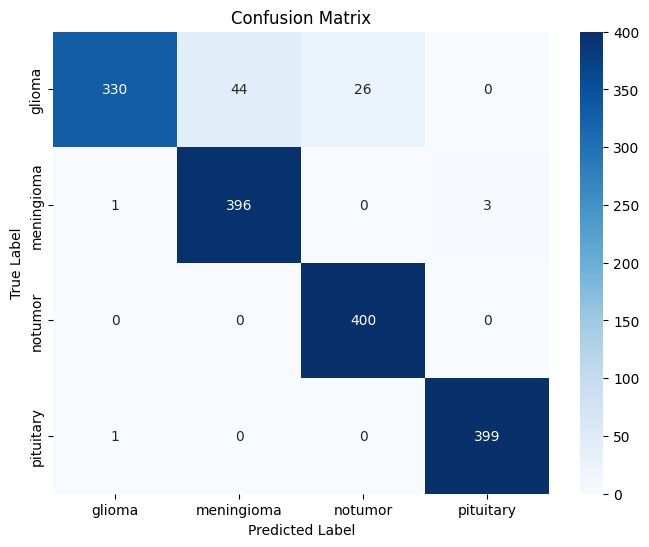

In [6]:
# 4. Evaluate Model (Accuracy & Confusion Matrix)
model.eval()
all_preds = []
all_labels = []

print("Running evaluation on Testing dataset...")
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate final accuracy
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nFinal Validation Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()